In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))
#

importing needed libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_data= pd.read_csv("/content/train (1).csv", on_bad_lines= 'skip')
test_data= pd.read_csv("/content/test.csv", on_bad_lines= 'skip')
val_data= pd.read_csv("/content/val.csv", on_bad_lines= 'skip')

In [ ]:
print(train_data.shape)
print(val_data.shape)
print(test_data.shape)

(1001, 10)
(145, 10)
(103, 10)


In [ ]:
train_data.head(10)

,User_ID,Age,Gender,Platform,Daily_Usage_Time (minutes),Posts_Per_Day,Likes_Received_Per_Day,Comments_Received_Per_Day,Messages_Sent_Per_Day,Dominant_Emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom
5,6,21,Male,Instagram,150.0,4.0,60.0,15.0,25.0,Happiness
6,7,27,Female,Twitter,85.0,3.0,30.0,10.0,18.0,Anger
7,8,24,Non-binary,Facebook,110.0,6.0,25.0,12.0,22.0,Sadness
8,9,29,Female,LinkedIn,55.0,2.0,10.0,3.0,8.0,Neutral
9,10,31,Male,Instagram,170.0,5.0,80.0,20.0,35.0,Happiness


In [ ]:
print(train_data.dtypes, '\n')
print(test_data.dtypes)

User_ID                        object
Age                            object
Gender                         object
Platform                       object
Daily_Usage_Time (minutes)    float64
Posts_Per_Day                 float64
Likes_Received_Per_Day        float64
Comments_Received_Per_Day     float64
Messages_Sent_Per_Day         float64
Dominant_Emotion               object
dtype: object 

User_ID                        int64
Age                           object
Gender                        object
Platform                      object
Daily_Usage_Time (minutes)     int64
Posts_Per_Day                  int64
Likes_Received_Per_Day         int64
Comments_Received_Per_Day      int64
Messages_Sent_Per_Day          int64
Dominant_Emotion              object
dtype: object


In [ ]:
def data_cleaning(df):
    df.dropna(inplace= True)
    df.columns= df.columns.str.lower()
    df= df[df['gender'].isin(['Male', 'Female', 'Non-binary'])]
    df.drop_duplicates(inplace= True)
    return df

checking for null values and handling them here since they can greatly effect the training with issues later on

In [ ]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())
print(val_data.isnull().sum())
train_data= data_cleaning(train_data)
train_data

User_ID                       0
Age                           0
Gender                        1
Platform                      1
Daily_Usage_Time (minutes)    1
Posts_Per_Day                 1
Likes_Received_Per_Day        1
Comments_Received_Per_Day     1
Messages_Sent_Per_Day         1
Dominant_Emotion              1
dtype: int64
User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              0
dtype: int64
User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              1
dtype: int64


,user_id,age,gender,platform,daily_usage_time (minutes),posts_per_day,likes_received_per_day,comments_received_per_day,messages_sent_per_day,dominant_emotion
0,1,25,Female,Instagram,120.0,3.0,45.0,10.0,12.0,Happiness
1,2,30,Male,Twitter,90.0,5.0,20.0,25.0,30.0,Anger
2,3,22,Non-binary,Facebook,60.0,2.0,15.0,5.0,20.0,Neutral
3,4,28,Female,Instagram,200.0,8.0,100.0,30.0,50.0,Anxiety
4,5,33,Male,LinkedIn,45.0,1.0,5.0,2.0,10.0,Boredom
...,...,...,...,...,...,...,...,...,...,...
996,996,33,Non-binary,Twitter,85.0,4.0,35.0,18.0,18.0,Boredom
997,997,22,Female,Facebook,70.0,1.0,14.0,6.0,10.0,Neutral
998,998,35,Male,Whatsapp,110.0,3.0,50.0,25.0,25.0,Happiness
999,999,28,Non-binary,Telegram,60.0,2.0,18.0,8.0,18.0,Anger


Removing null values from the data and replacint them after

In [ ]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())
print(val_data.isnull().sum())

user_id                       0
age                           0
gender                        0
platform                      0
daily_usage_time (minutes)    0
posts_per_day                 0
likes_received_per_day        0
comments_received_per_day     0
messages_sent_per_day         0
dominant_emotion              0
dtype: int64
User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              0
dtype: int64
User_ID                       0
Age                           0
Gender                        0
Platform                      0
Daily_Usage_Time (minutes)    0
Posts_Per_Day                 0
Likes_Received_Per_Day        0
Comments_Received_Per_Day     0
Messages_Sent_Per_Day         0
Dominant_Emotion              1
dtype: int64


In [ ]:
def count_plt(df, x, hue=None, title=None):
    plt.figure(figsize=(15, 8))
    countplot = sns.countplot(data=df, x=x, hue=hue)
    for container in countplot.containers:
        countplot.bar_label(container)

    countplot.yaxis.set_visible(False)
    if title:
        plt.title(title, fontsize=16)
    plt.show()

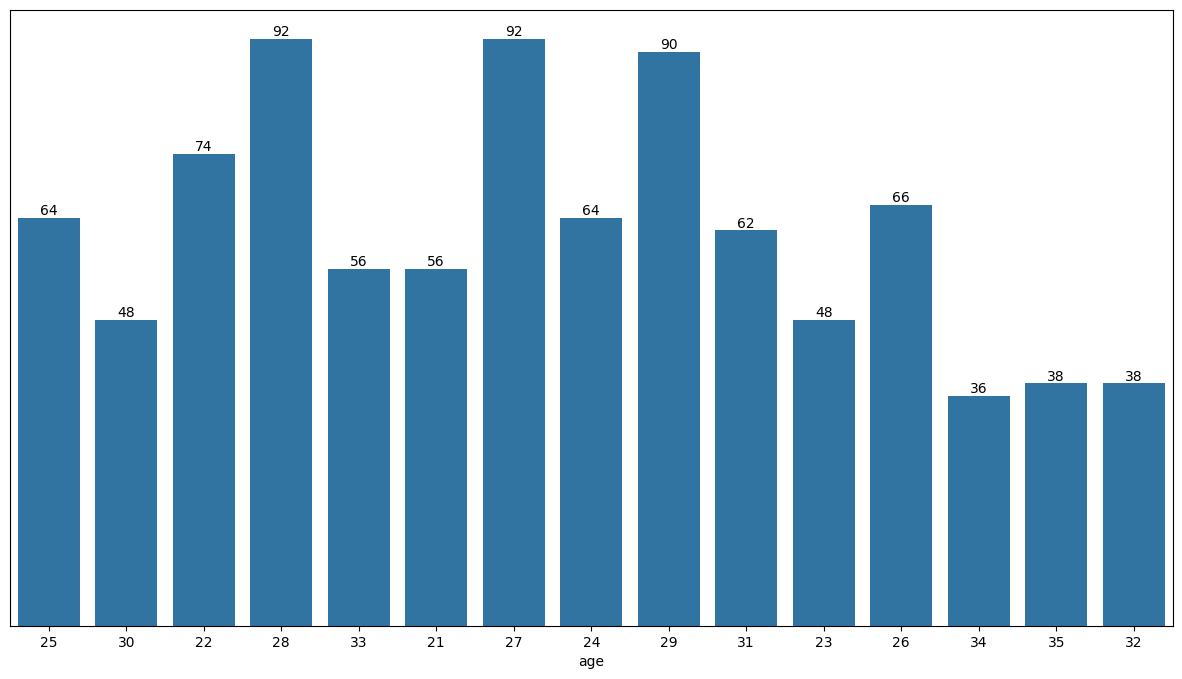

In [ ]:
count_plt(train_data, 'age')

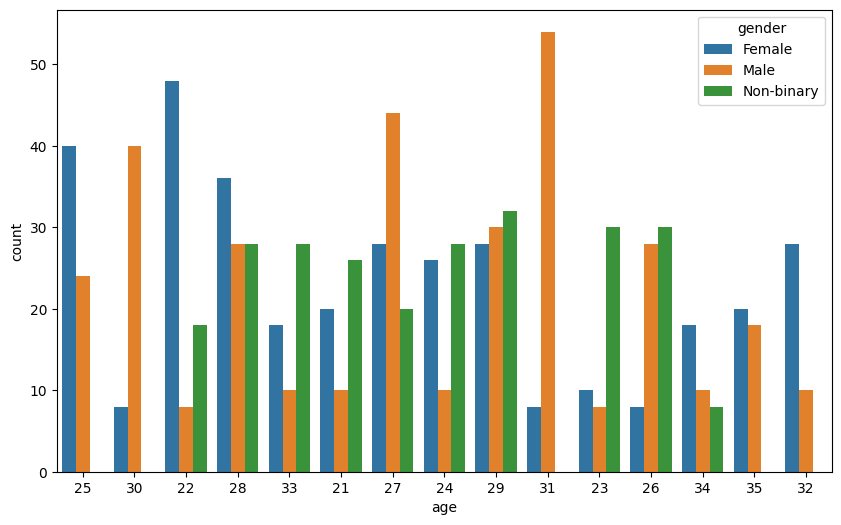

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(train_data, x='age', hue='gender')
plt.show()

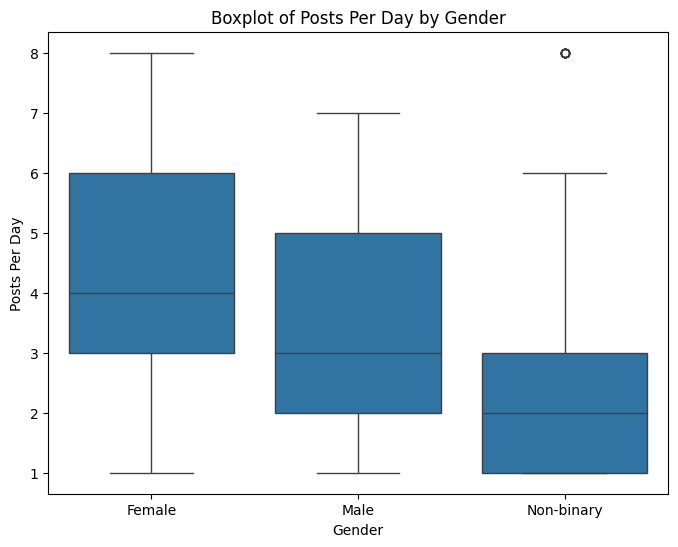

In [ ]:
plt.figure(figsize=(8, 6))  # Optional: Adjust the figure size
sns.boxplot(data=train_data, x='gender', y='posts_per_day')
plt.title('Boxplot of Posts Per Day by Gender')
plt.xlabel('Gender')
plt.ylabel('Posts Per Day')
plt.show()

<Axes: xlabel='posts_per_day', ylabel='Count'>

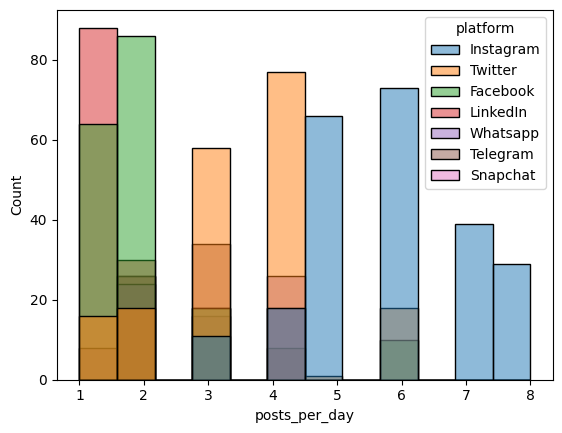

In [ ]:
sns.histplot(data=train_data, x='posts_per_day', hue='platform')

<Axes: xlabel='dominant_emotion', ylabel='Count'>

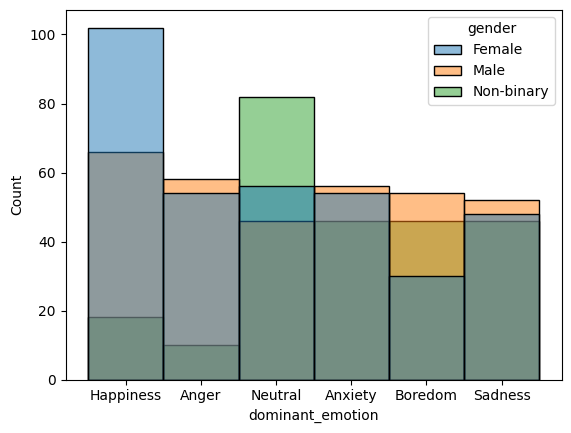

In [ ]:
sns.histplot(data=train_data, x='dominant_emotion', hue = 'gender')

<Axes: xlabel='age', ylabel='count'>

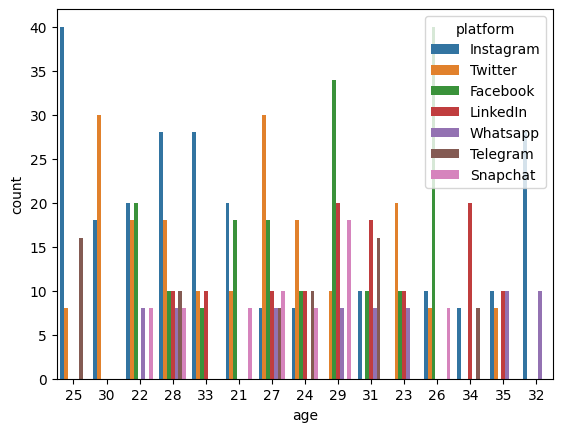

In [ ]:
sns.countplot(data=train_data, x='age', hue = 'platform')

<Axes: xlabel='age', ylabel='dominant_emotion'>

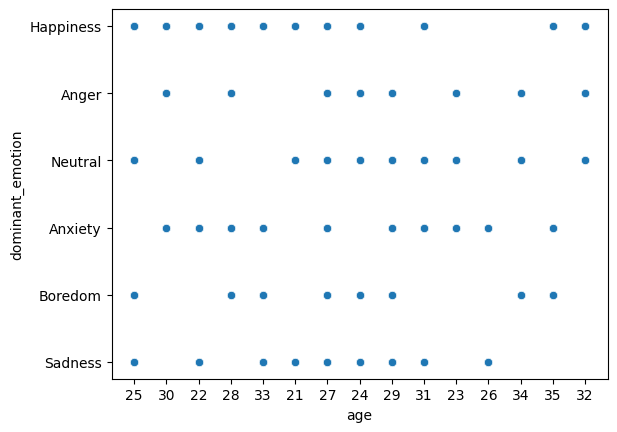

In [ ]:
sns.scatterplot(data=train_data, x= 'age', y= 'dominant_emotion')

In [ ]:
emotion_colors = {
    'Anger': 'red',
    'Happiness': 'yellow',
    'Sadness': 'blue',
    'Neutral': 'gray',
    'Anxiety': 'purple',
    'Boredom': 'green'
}

<Axes: xlabel='age', ylabel='platform'>

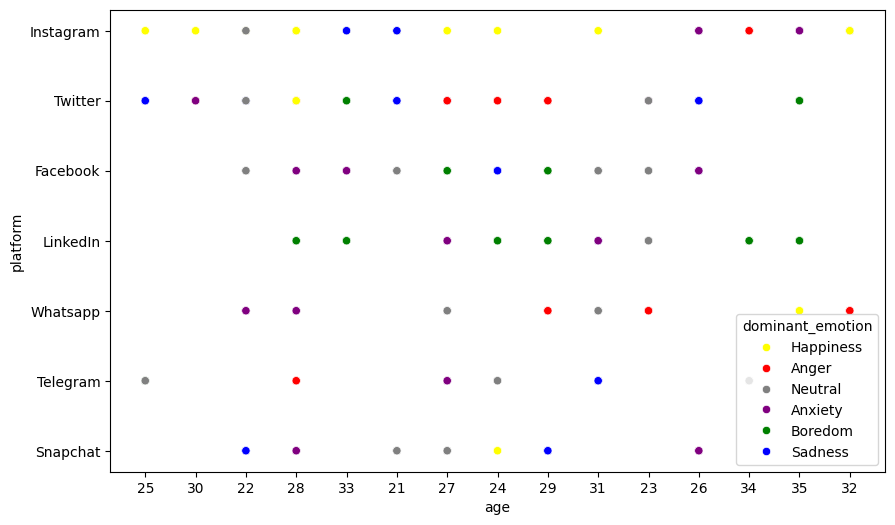

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train_data, x='age', y='platform', hue='dominant_emotion', palette=emotion_colors)

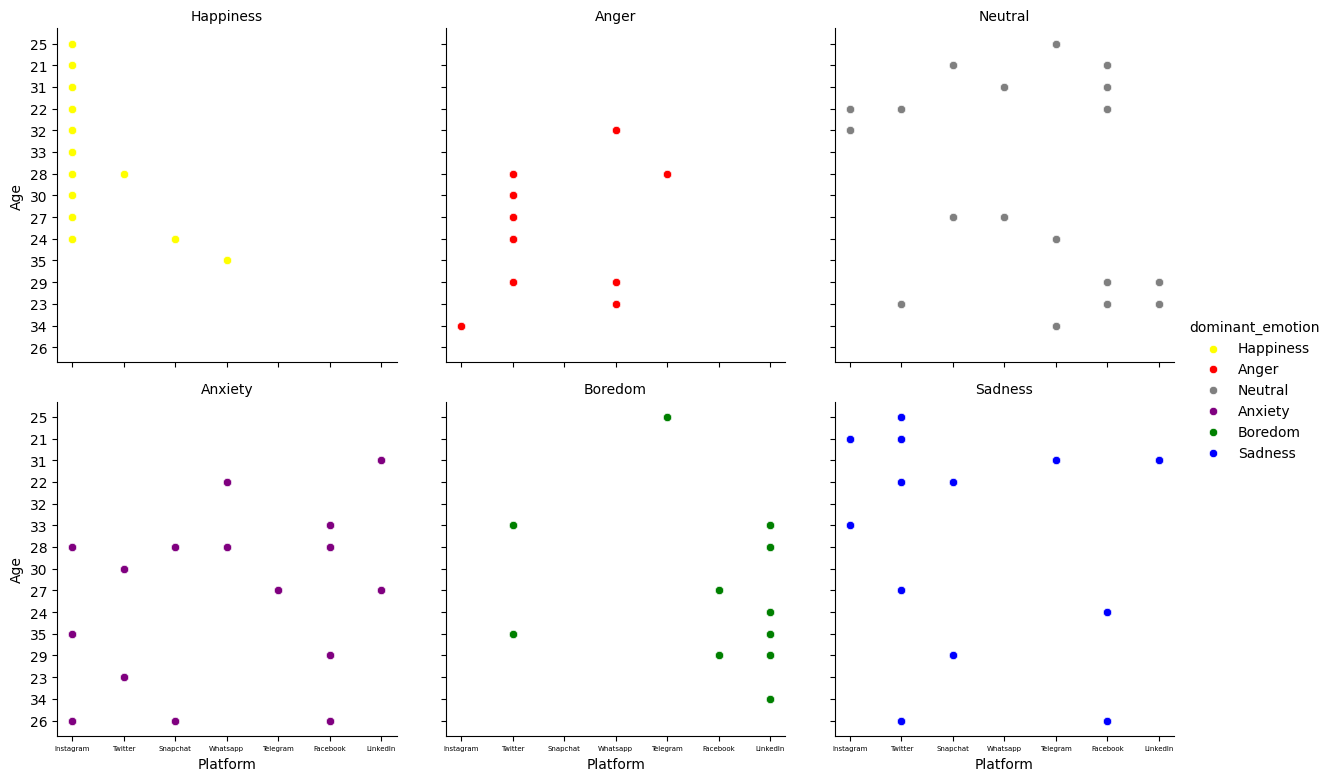

In [ ]:

g = sns.FacetGrid(train_data, col='dominant_emotion', hue='dominant_emotion', col_wrap=3, height=4, palette=emotion_colors)

g.map(sns.scatterplot, 'platform', 'age')

g.add_legend()
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Platform", "Age")

for ax in g.axes.flatten():
    ax.tick_params(axis='x', labelsize=5)  # Adjust labelsize to your preference

# Show the plot
plt.show()

Likely because of the algorithms on each site they are able to get more of particular emotions like instagram having a major happiness spike over the largest age range.

<Axes: xlabel='gender', ylabel='comments_received_per_day'>

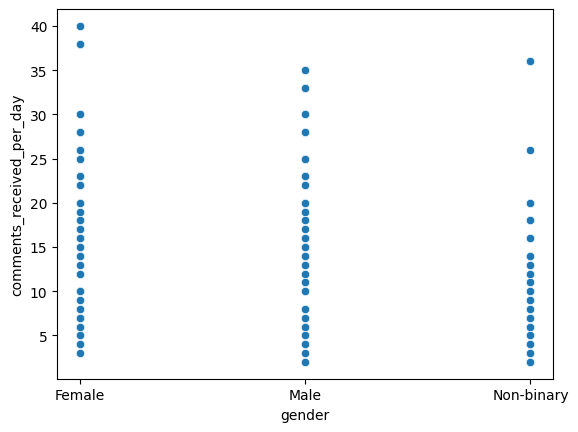

In [ ]:
sns.scatterplot(data=train_data, x='gender', y='comments_received_per_day', palette=emotion_colors)

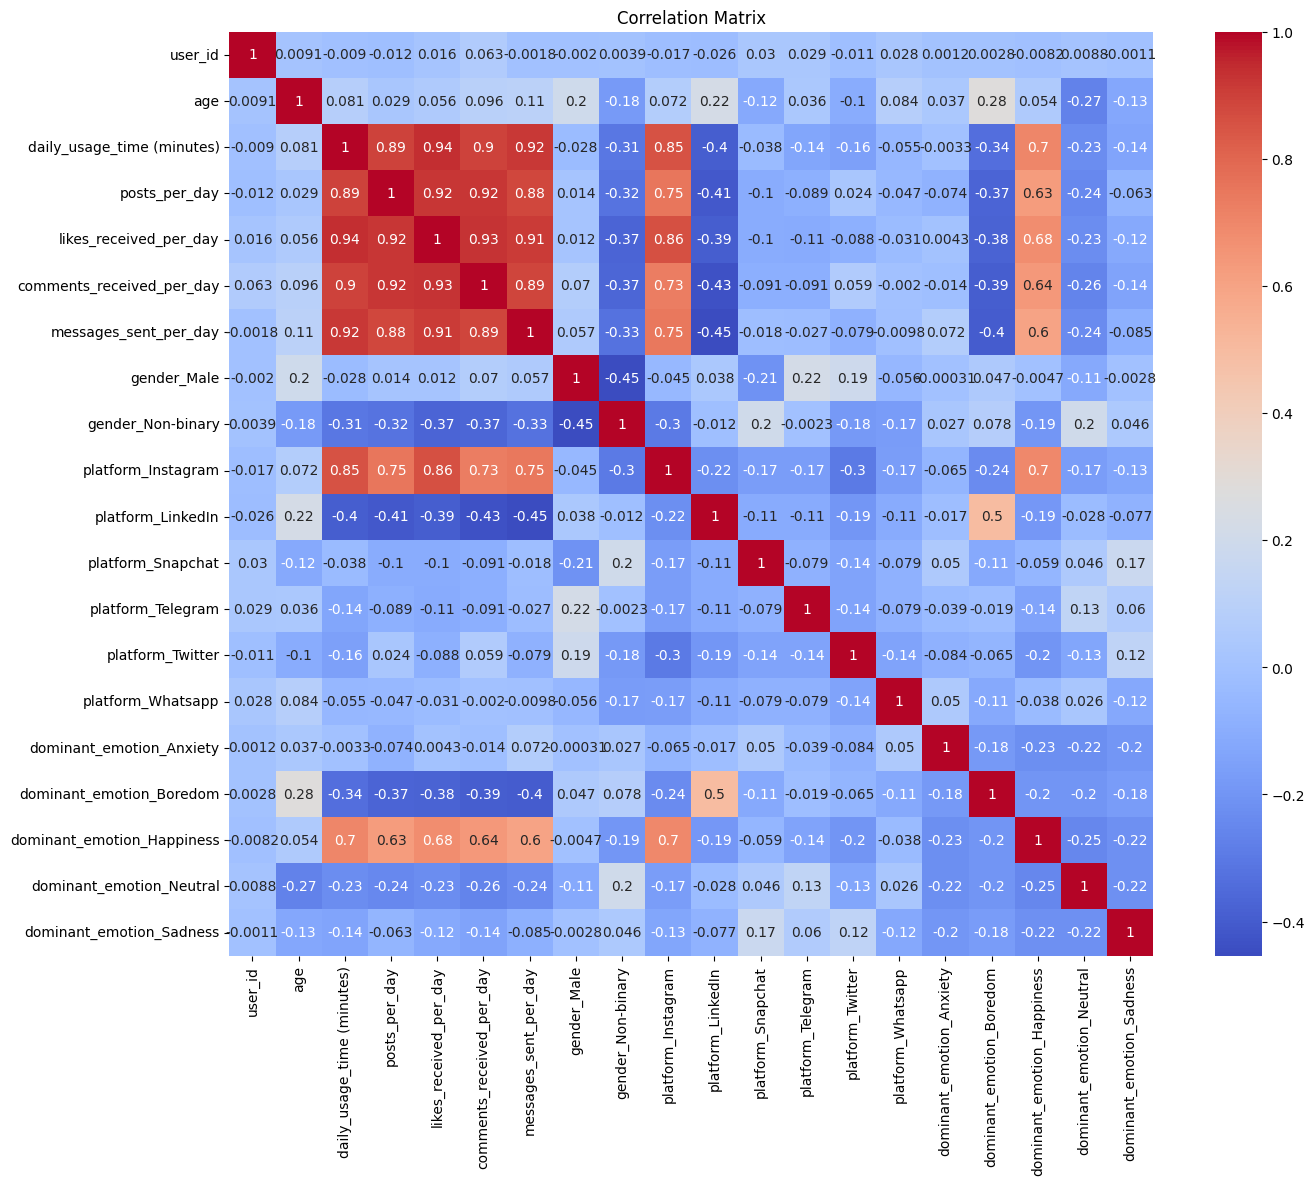

In [ ]:
df_encoded = pd.get_dummies(train_data, columns=['gender', 'platform','dominant_emotion'], drop_first=True)
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

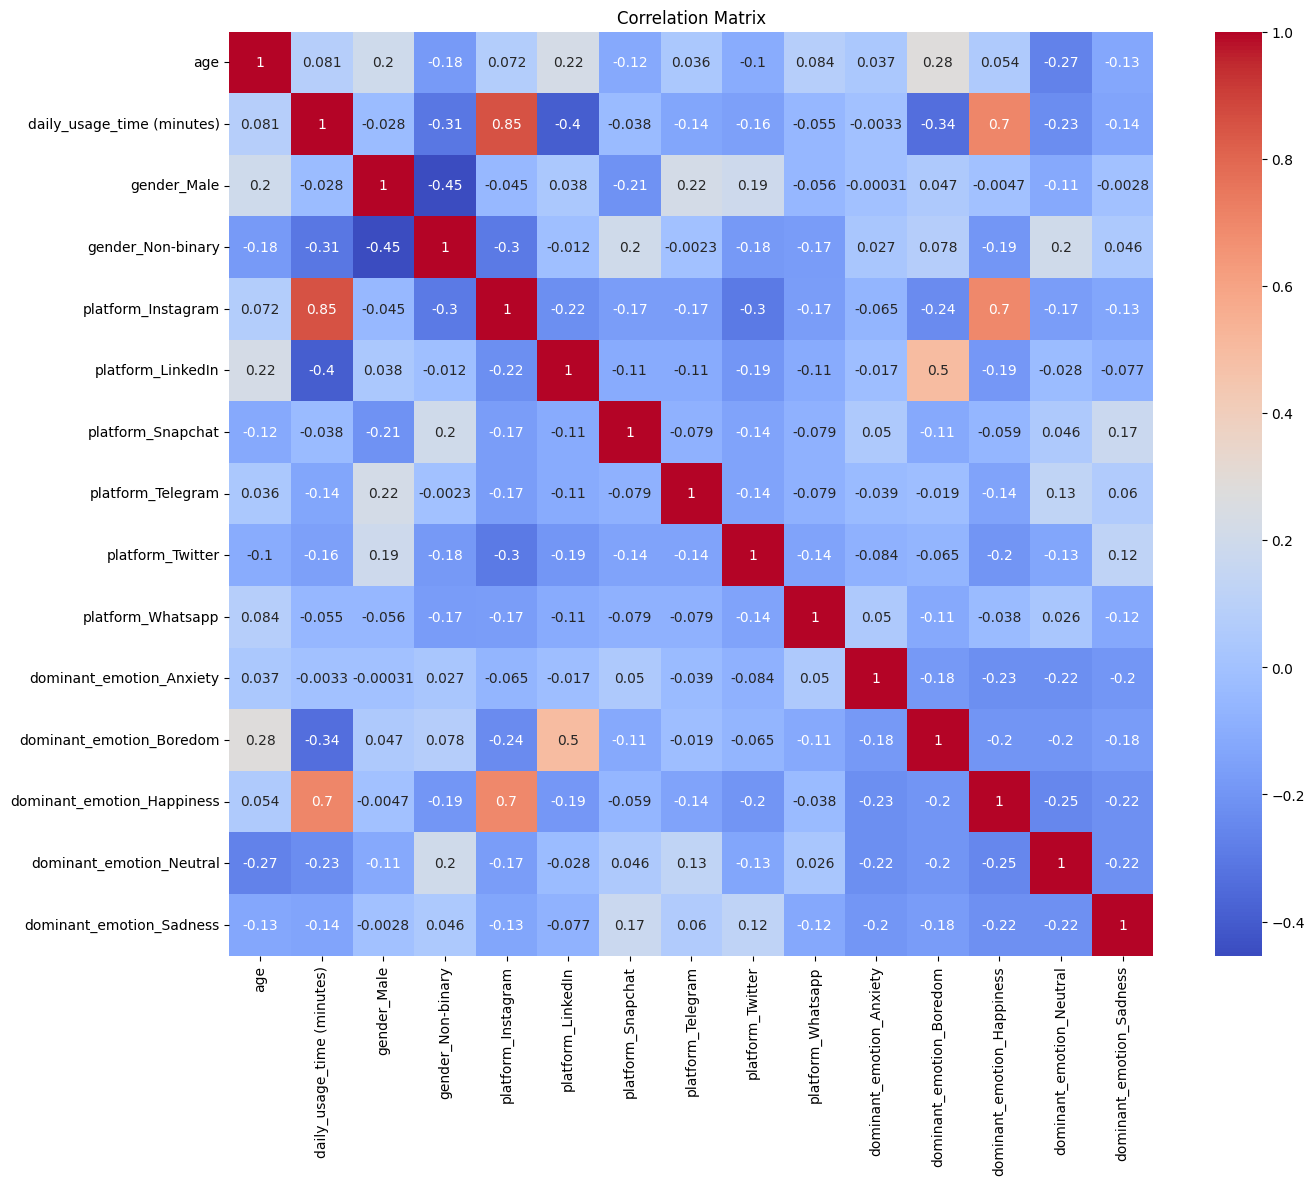

In [ ]:
dropped_df = df_encoded.drop(columns=['posts_per_day', 'likes_received_per_day', 'comments_received_per_day', 'user_id', 'messages_sent_per_day'])
correlation_matrix = dropped_df.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

K-Means Clustering


In [ ]:
df_encoded.head()


,user_id,age,daily_usage_time (minutes),posts_per_day,likes_received_per_day,comments_received_per_day,messages_sent_per_day,gender_Male,gender_Non-binary,platform_Instagram,...,platform_Snapchat,platform_Telegram,platform_Twitter,platform_Whatsapp,dominant_emotion_Anxiety,dominant_emotion_Boredom,dominant_emotion_Happiness,dominant_emotion_Neutral,dominant_emotion_Sadness,Cluster
0,1,25,120.0,3.0,45.0,10.0,12.0,False,False,True,...,False,False,False,False,False,False,True,False,False,2
1,2,30,90.0,5.0,20.0,25.0,30.0,True,False,False,...,False,False,True,False,False,False,False,False,False,2
2,3,22,60.0,2.0,15.0,5.0,20.0,False,True,False,...,False,False,False,False,False,False,False,True,False,2
3,4,28,200.0,8.0,100.0,30.0,50.0,False,False,True,...,False,False,False,False,True,False,False,False,False,2
4,5,33,45.0,1.0,5.0,2.0,10.0,True,False,False,...,False,False,False,False,False,True,False,False,False,2


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score


In [ ]:
# Load data
data = pd.read_csv("/content/train (1).csv")

# Check the data structure
print(data.head())


  User_ID Age      Gender   Platform  Daily_Usage_Time (minutes)  \
0       1  25      Female  Instagram                       120.0   
1       2  30        Male    Twitter                        90.0   
2       3  22  Non-binary   Facebook                        60.0   
3       4  28      Female  Instagram                       200.0   
4       5  33        Male   LinkedIn                        45.0   

   Posts_Per_Day  Likes_Received_Per_Day  Comments_Received_Per_Day  \
0            3.0                    45.0                       10.0   
1            5.0                    20.0                       25.0   
2            2.0                    15.0                        5.0   
3            8.0                   100.0                       30.0   
4            1.0                     5.0                        2.0   

   Messages_Sent_Per_Day Dominant_Emotion  
0                   12.0        Happiness  
1                   30.0            Anger  
2                   20.0        

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Fix the 'Age' column
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')  # Convert Age to numeric
data['Age'].fillna(data['Age'].median(), inplace=True)     # Fill missing Age values with median

# Encode categorical variables
label_encoder = LabelEncoder()
data['Gender'] = label_encoder.fit_transform(data['Gender'])  # Encode Gender
data['Platform'] = label_encoder.fit_transform(data['Platform'])  # Encode Platform
data['Dominant_Emotion'] = label_encoder.fit_transform(data['Dominant_Emotion'])  # Encode Emotion

# Select features (X) and target (y)
X = data.drop(['User_ID', 'Dominant_Emotion'], axis=1)  # Features
y = data['Dominant_Emotion']  # Target

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verify preprocessing steps
print("Data Types:\n", X.dtypes)
print("\nFirst 5 rows of scaled features:\n", pd.DataFrame(X_scaled).head())
print("\nFirst 5 target values:\n", y.head())



Data Types:
 Age                           float64
Gender                          int64
Platform                        int64
Daily_Usage_Time (minutes)    float64
Posts_Per_Day                 float64
Likes_Received_Per_Day        float64
Comments_Received_Per_Day     float64
Messages_Sent_Per_Day         float64
dtype: object

First 5 rows of scaled features:
           0         1         2         3         4         5         6  \
0 -0.649973 -0.070206 -0.746538  0.619350 -0.167745  0.193399 -0.636523   
1  0.670285  0.290185  1.199516 -0.153228  0.877393 -0.754264  1.065106   
2 -1.442128  0.650576 -1.233052 -0.925806 -0.690313 -0.943797 -1.203732   
3  0.142182 -0.070206 -0.746538  2.679559  2.445098  2.278259  1.632316   
4  1.462439  0.290185 -0.260025 -1.312096 -1.212882 -1.322863 -1.544058   

          7  
0 -1.240599  
1  0.874059  
2 -0.300751  
3  3.223679  
4 -1.475561  

First 5 target values:
 0    3
1    0
2    4
3    1
4    2
Name: Dominant_Emotion, dtype: int64


<ipython-input-4-2a348ac5a8f5>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)     # Fill missing Age values with median


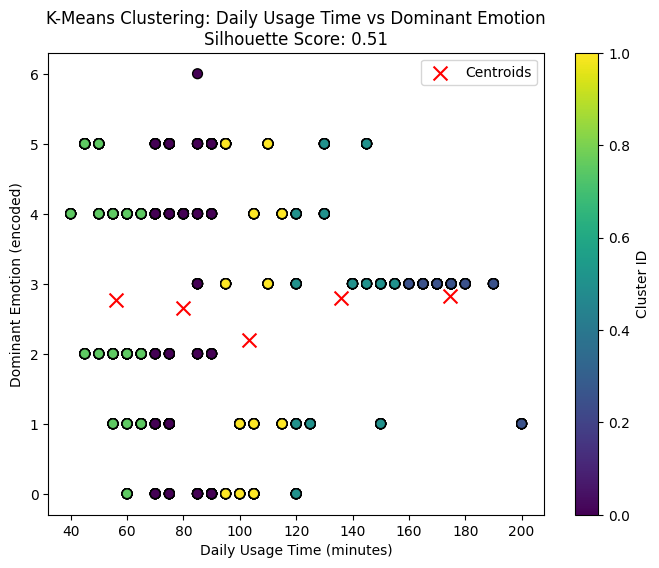

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Selecting relevant columns for clustering
X_reduced = data[['Daily_Usage_Time (minutes)', 'Dominant_Emotion']]

# Handle missing values in usage time
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_reduced[['Daily_Usage_Time (minutes)']])  # Only impute for Daily_Usage_Time

# Encode 'Dominant_Emotion' (target) into numeric values for clustering
label_encoder = LabelEncoder()
X_imputed = np.column_stack((X_imputed, label_encoder.fit_transform(data['Dominant_Emotion'])))

# Apply K-means clustering (let's assume 5 clusters, one per emotion)
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_imputed)

# Calculate silhouette score
silhouette_avg = silhouette_score(X_imputed, y_kmeans)

# Plotting the clustering results with silhouette score
plt.figure(figsize=(8, 6))

# Scatter plot of Daily Usage Time vs Dominant Emotion, colored by cluster label
plt.scatter(X_imputed[:, 0], X_imputed[:, 1], c=y_kmeans, cmap='viridis', s=50, edgecolors='k')

# Plot the cluster centers (centroids)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100, label='Centroids')

# Display silhouette score on the plot
plt.title(f'K-Means Clustering: Daily Usage Time vs Dominant Emotion\nSilhouette Score: {silhouette_avg:.2f}')
plt.xlabel('Daily Usage Time (minutes)')
plt.ylabel('Dominant Emotion (encoded)')
plt.colorbar(label='Cluster ID')
plt.legend()
plt.show()



In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

# Ensure the model is fitted
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(X_scaled)  # Fit the KMeans model
labels = kmeans.labels_  # Get the labels (cluster assignments)

# Compute the silhouette score and silhouette values
silhouette_avg = silhouette_score(X_scaled, labels)
silhouette_values = silhouette_samples(X_scaled, labels)

print(f"Average Silhouette Score: {silhouette_avg:.2f}")

# Plotting the silhouette values for each cluster
fig, ax = plt.subplots(figsize=(10, 6))

# Variables for plotting
y_lower = 10  # For spacing
n_clusters = len(set(labels))  # Number of clusters
colors = cm.nipy_spectral(labels.astype(float) / n_clusters)

for i in range(n_clusters):
    # Aggregate silhouette scores for samples in the same cluster
    ith_cluster_silhouette_values = silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()

    # Determine the size of the cluster
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Fill the plot
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=colors[i],
        edgecolor=colors[i],
        alpha=0.7
    )

    # Label the silhouette plots with their cluster numbers
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # Add space between plots

# Add labels and title
ax.set_title("Silhouette Plot for K-means Clustering")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.axvline(x=silhouette_avg, color="red", linestyle="--")
ax.set_yticks([])  # Clear y-axis labels
ax.set_xlim([-0.1, 1])  # Silhouette score ranges between -1, 1
plt.tight_layout()
plt.show()



NameError: name 'n_clusters' is not defined